In [190]:
import json
import matplotlib.pyplot as plt
import numpy as np

In [191]:
def load_json_file(file_path):
	try:
		with open(file_path, 'r') as file:
			data = json.load(file)
		return data
	
	except Exception as e:
		print(f"An error occurred while loading the JSON file: {e}")
		return None

In [192]:
def chunk_list(lst, chunk_size):
    # Slices the list into chunks of the specified size
    return [lst[i:i + chunk_size] for i in range(0, len(lst), chunk_size)]

In [193]:
colors = [
	'#e6194B',
	'#f58231',
	'#9A6324',
	'#911eb4',
	'#3cb44b',
	'#f032e6',
	'#4363d8',
  	'#f7cc1d',
]

In [194]:
def plot_one_line(xs, ys, x_label, y_label, label, plot_size=(24, 4), line_color=colors[0], label_size=16, font_size=24, legend_size=16):
	fig, ax1 = plt.subplots(figsize=plot_size)
	
	ax1.plot(xs, ys, color=line_color, label=label, marker='o')

	ax1.set_xlabel(x_label, fontsize=font_size)
	ax1.set_ylabel(y_label, fontsize=font_size)
	# ax1.set_title(title, fontsize=font_size)
	plt.xticks(fontsize=label_size)
	plt.yticks(fontsize=label_size)
	# plt.legend(fontsize=legend_size)
	# plt.xlim([0, 1000])
	plt.grid(True)

	plt.show()

In [195]:
range_left = 800
range_right = 1000

In [196]:
def process_input(input_filepath, chunk_size):
	input_result = load_json_file(input_filepath)
	latency_list = input_result['latency_list']
	latency_list.pop(0)

	chunked_latency_list = chunk_list(latency_list, chunk_size)
	chunk_latency_average = [float(np.average(np.array(chunk))) for chunk in chunked_latency_list]
	chunk_latency_std = [float(np.std(np.array(chunk))) for chunk in chunked_latency_list]
	chunk_latency_ratio = list(np.array(chunk_latency_std) / np.array(chunk_latency_average))

	chunk_fps_average = list(1 / np.array(chunk_latency_average))

	xs = [i * chunk_size for i in range(len(chunked_latency_list))]

	print(f"Filename: {input_filepath}")
	print(f"Chunk Size: {chunk_size}")
	plot_one_line(xs[:], chunk_fps_average[:], 'Frame Index', 'Chunk FPS', '')
	# plot_one_line(xs, chunk_latency_ratio, 'Frame Index', 'Chunk STD/AVG', '')

	cpu_freq_list = input_result['cpu_freq_list']
	gpu_freq_list = input_result['gpu_freq_list']
	emc_freq_list = input_result['emc_freq_list']

	chunk_cpu_freq_average = [float(np.average(np.array(chunk))) for chunk in chunk_list(cpu_freq_list, chunk_size)]
	chunk_gpu_freq_average = [float(np.average(np.array(chunk))) for chunk in chunk_list(gpu_freq_list, chunk_size)]
	chunk_emc_freq_average = [float(np.average(np.array(chunk))) for chunk in chunk_list(emc_freq_list, chunk_size)]

	plot_one_line(xs[:], chunk_cpu_freq_average[:], 'Frame Index', 'CPU Frequency', '')
	# plot_one_line(xs, chunk_gpu_freq_average, 'Frame Index', 'GPU Frequency', '')
	# plot_one_line(xs, chunk_emc_freq_average, 'Frame Index', 'EMC Frequency', '')

	cpu_temp_list = input_result['cpu_temp_list']
	gpu_temp_list = input_result['gpu_temp_list']

	chunk_cpu_temp_average = [float(np.average(np.array(chunk))) for chunk in chunk_list(cpu_temp_list, chunk_size)]
	chunk_gpu_temp_average = [float(np.average(np.array(chunk))) for chunk in chunk_list(gpu_temp_list, chunk_size)]

	plot_one_line(xs[:], chunk_cpu_temp_average[:], 'Frame Index', 'CPU Temperature', '')
	# plot_one_line(xs, chunk_gpu_temp_average, 'Frame Index', 'GPU Temperature', '')

Filename: ./Latency.json
Chunk Size: 30


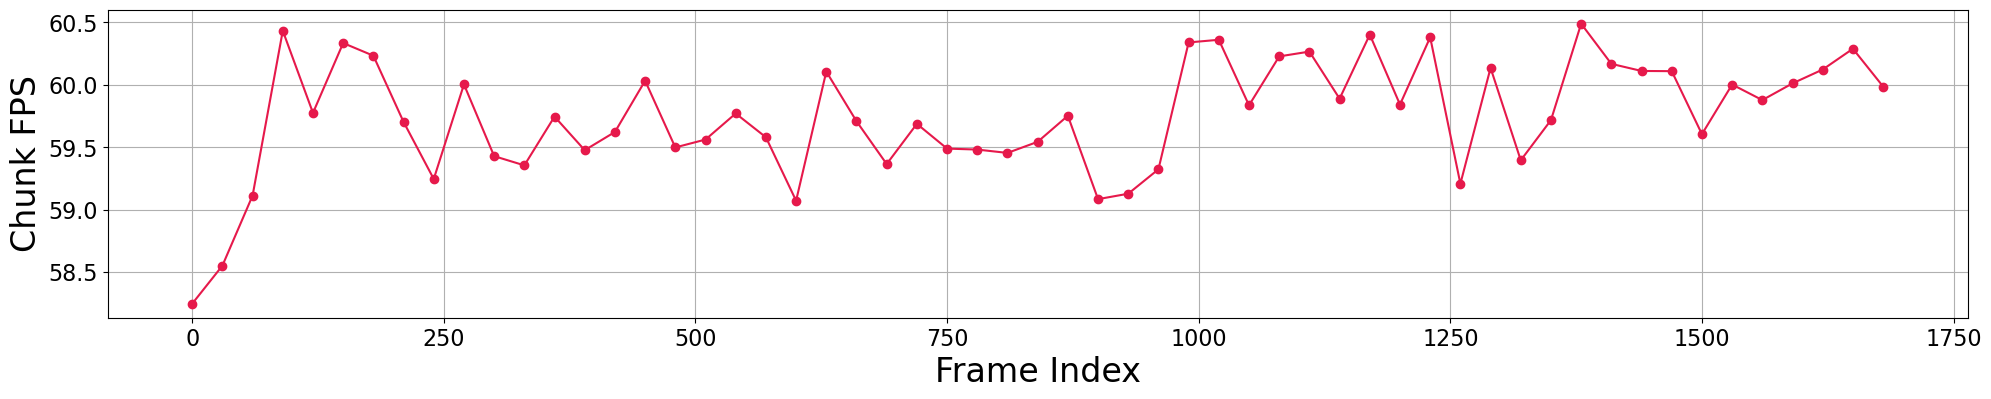

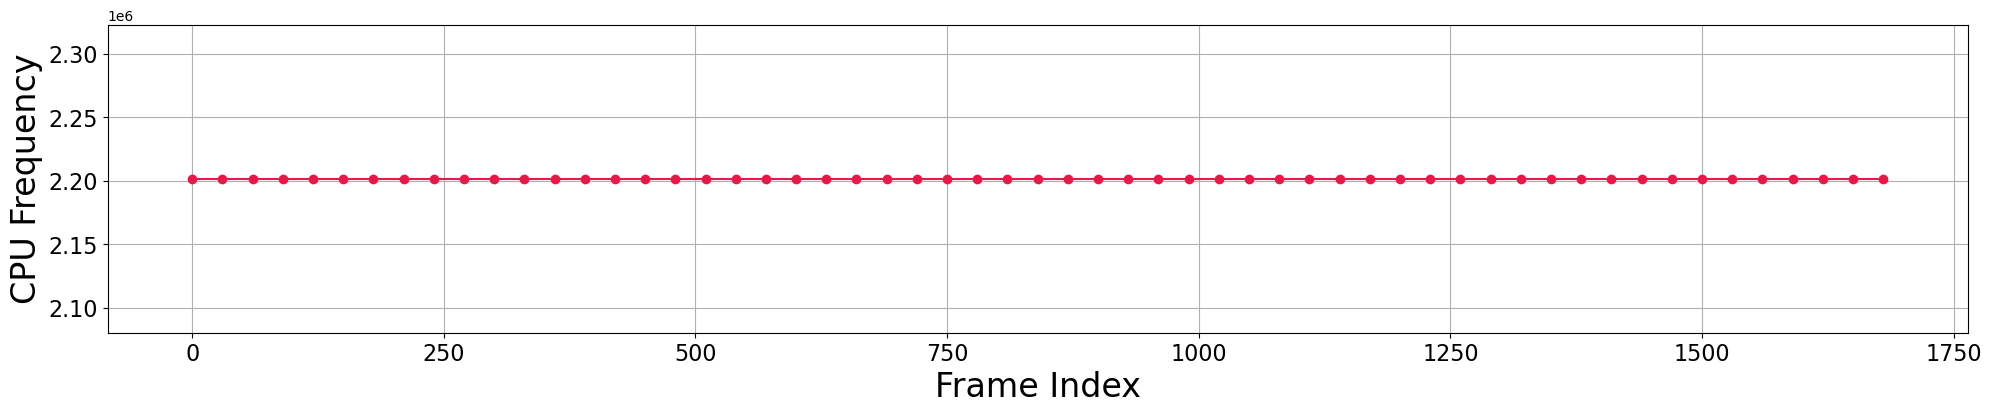

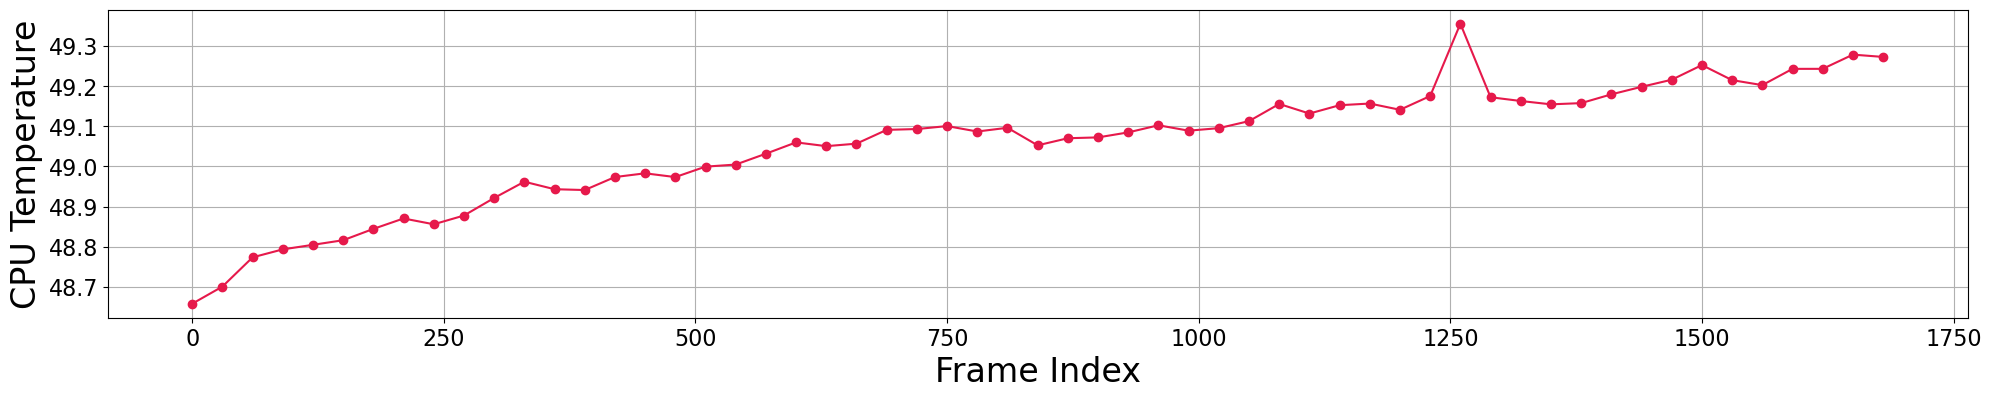

In [197]:
process_input('./Latency.json', 30)